In [ ]:
# Part 6 — Hands-On Preference Training with a Small LLM

#  Part 6 — From Concepts to Real Model Code
 
We will understand three things:

1. How an LLM assigns probabilities to responses
2. How to compare a chosen and rejected response
3. What preference optimization is trying to change

We will use a small model so that everything remains understandable.

In [1]:
!pip install -q transformers torch


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)

model.eval()

print("Model loaded:", model_name)

Model loaded: distilgpt2


In [3]:
text = "Gravity pulls objects toward Earth."

tokens = tokenizer(text, return_tensors="pt")

print(tokens)

{'input_ids': tensor([[   38, 16995, 16194,  5563,  3812,  3668,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


In [4]:
print("Token IDs:")
print(tokens["input_ids"])

print("\nDecoded tokens:")

for token_id in tokens["input_ids"][0]:
    print(
        token_id.item(),
        "→",
        tokenizer.decode([token_id])
    )

Token IDs:
tensor([[   38, 16995, 16194,  5563,  3812,  3668,    13]])

Decoded tokens:
38 → G
16995 → ravity
16194 →  pulls
5563 →  objects
3812 →  toward
3668 →  Earth
13 → .


#  Remember the Policy?

Earlier we wrote:

π(token | prompt, previous tokens)

A language model assigns a probability to every possible
next token.

Example:

"The sky is"

blue  → high probability

green → lower probability

banana → very low probability

When the model generates a full response, it repeatedly
samples or selects tokens from these probability distributions.

In [7]:
prompt = "The capital of France is"

inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

next_token_logits = logits[0, -1]

probabilities = torch.softmax(next_token_logits, dim=-1)

top_k = torch.topk(probabilities, 10)

for probability, token_id in zip(
    top_k.values,
    top_k.indices
):
    token = tokenizer.decode([token_id])

    print(
        repr(token),
        "→",
        f"{probability.item():.4f}"
    )

' the' → 0.1177
' home' → 0.0823
' now' → 0.0499
' a' → 0.0493
' being' → 0.0356
' one' → 0.0211
' known' → 0.0189
' also' → 0.0188
' in' → 0.0180
' to' → 0.0140


In [8]:
prompt = "Explain gravity simply:\n"

inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():

    output_ids = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.8
    )

result = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Explain gravity simply:











































In [9]:
prompt = "Explain gravity to a 10-year-old."

chosen = """
Gravity is like an invisible pull that keeps your feet on the
ground and makes things fall toward Earth.
"""

rejected = """
Gravity is a manifestation of spacetime curvature described
through differential geometry and gravitational field equations.
"""

print("PROMPT")
print(prompt)

print("\nCHOSEN")
print(chosen)

print("\nREJECTED")
print(rejected)

PROMPT
Explain gravity to a 10-year-old.

CHOSEN

Gravity is like an invisible pull that keeps your feet on the
ground and makes things fall toward Earth.


REJECTED

Gravity is a manifestation of spacetime curvature described
through differential geometry and gravitational field equations.



#  What Does Model Preference Mean?

Humans can say:

Chosen > Rejected

But an LLM represents preference through probabilities.

We can ask:

> How probable does the model consider this response
> given the prompt?

Conceptually:

P(response | prompt)

A response that receives higher probability is more compatible
with the model's current policy.

In [10]:
def response_log_probability(model, tokenizer, prompt, response):

    full_text = prompt + response

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt"
    )

    prompt_tokens = tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = full_tokens["input_ids"]

    prompt_length = prompt_tokens["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model(input_ids=input_ids)

    logits = outputs.logits[:, :-1, :]

    target_ids = input_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)

    token_log_probs = log_probs.gather(
        2,
        target_ids.unsqueeze(-1)
    ).squeeze(-1)

    # Response begins after the prompt.
    response_log_probs = token_log_probs[
        :,
        prompt_length - 1:
    ]

    total_log_prob = response_log_probs.sum()

    return total_log_prob.item()

In [11]:
chosen_score = response_log_probability(
    model,
    tokenizer,
    prompt,
    chosen
)

rejected_score = response_log_probability(
    model,
    tokenizer,
    prompt,
    rejected
)

print("Chosen log probability :", chosen_score)
print("Rejected log probability:", rejected_score)

Chosen log probability : -105.70609283447266
Rejected log probability: -88.20101165771484


In [12]:
# Normalizing by length

In [13]:
def average_response_log_probability(
    model,
    tokenizer,
    prompt,
    response
):

    full_text = prompt + response

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt"
    )

    prompt_tokens = tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = full_tokens["input_ids"]

    prompt_length = prompt_tokens["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model(input_ids=input_ids)

    logits = outputs.logits[:, :-1, :]

    target_ids = input_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)

    token_log_probs = log_probs.gather(
        2,
        target_ids.unsqueeze(-1)
    ).squeeze(-1)

    response_log_probs = token_log_probs[
        :,
        prompt_length - 1:
    ]

    return response_log_probs.mean().item()

In [14]:
chosen_score = average_response_log_probability(
    model,
    tokenizer,
    prompt,
    chosen
)

rejected_score = average_response_log_probability(
    model,
    tokenizer,
    prompt,
    rejected
)

print("Chosen average log probability :", chosen_score)
print("Rejected average log probability:", rejected_score)

Chosen average log probability : -4.404420375823975
Rejected average log probability: -4.00913667678833


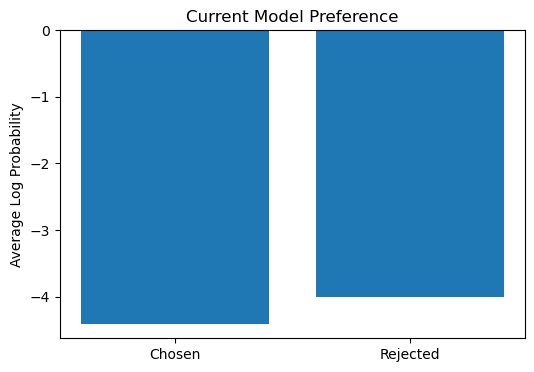

In [15]:
# Visualizing preferences

import matplotlib.pyplot as plt

labels = ["Chosen", "Rejected"]
scores = [chosen_score, rejected_score]

plt.figure(figsize=(6, 4))

plt.bar(labels, scores)

plt.ylabel("Average Log Probability")
plt.title("Current Model Preference")

plt.show()

#  What Should Preference Training Change?

Human says:
    Chosen > Rejected

Suppose the model currently gives:
        Chosen   → -4.2
                        \
        Rejected → -3.1

The model currently considers the rejected response more likely.

Preference optimization should change the model so that, relative to the reference model:

Chosen becomes more likely

and/or

Rejected becomes less likely.

In [17]:
preference_data = [
    {
        "prompt": "Explain machine learning simply.",
        "chosen": "Machine learning lets computers learn patterns from examples.",
        "rejected": "Machine learning involves optimizing parameterized statistical estimators."
    },

    {
        "prompt": "Explain the Moon to a child.",
        "chosen": "The Moon is a rocky world that travels around Earth.",
        "rejected": "The Moon is a tidally locked astronomical body with a radius of 1,737 km."
    },

    {
        "prompt": "Explain gravity to a child.",
        "chosen": "Gravity is the invisible pull that keeps us on Earth.",
        "rejected": "Gravity results from the curvature of four-dimensional spacetime."
    }
]

print("Number of preference pairs:", len(preference_data))

Number of preference pairs: 3


In [19]:
for i, example in enumerate(preference_data):

    chosen_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["chosen"]
    )

    rejected_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["rejected"]
    )

    print(f"\nExample {i+1}")

    print(
        "Chosen   :",
        round(chosen_score, 3)
    )

    print(
        "Rejected :",
        round(rejected_score, 3)
    )

    if chosen_score > rejected_score:
        print("Model currently agrees with human preference  ")
    else:
        print("Model currently disagrees with human preference ")


Example 1
Chosen   : -4.762
Rejected : -5.226
Model currently agrees with human preference  

Example 2
Chosen   : -3.522
Rejected : -3.391
Model currently disagrees with human preference 

Example 3
Chosen   : -4.188
Rejected : -3.218
Model currently disagrees with human preference 


In [20]:
correct = 0

for example in preference_data:

    chosen_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["chosen"]
    )

    rejected_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["rejected"]
    )

    if chosen_score > rejected_score:
        correct += 1


accuracy = correct / len(preference_data)

print(
    "Preference agreement:",
    f"{accuracy:.0%}"
)

Preference agreement: 33%


In [21]:
# Reference model

import copy

reference_model = copy.deepcopy(model)

reference_model.eval()

for param in reference_model.parameters():
    param.requires_grad = False

print("Frozen reference model created.")

Frozen reference model created.


In [ ]:
#  Why Keep Two Models?

At the beginning:
    Policy Model ≈ Reference Model

Then preference training modifies only:

    Policy Model
    The Reference Model remains frozen.

This lets us ask:

> Has the policy become relatively more likely to generate
> the chosen response than the reference model?

In [22]:
def preference_signal(
    policy_model,
    reference_model,
    tokenizer,
    prompt,
    chosen,
    rejected,
    beta=0.1
):

    p_chosen = average_response_log_probability(
        policy_model,
        tokenizer,
        prompt,
        chosen
    )

    p_rejected = average_response_log_probability(
        policy_model,
        tokenizer,
        prompt,
        rejected
    )

    r_chosen = average_response_log_probability(
        reference_model,
        tokenizer,
        prompt,
        chosen
    )

    r_rejected = average_response_log_probability(
        reference_model,
        tokenizer,
        prompt,
        rejected
    )

    signal = beta * (
        (p_chosen - r_chosen)
        -
        (p_rejected - r_rejected)
    )

    return signal

In [23]:
example = preference_data[0]

signal = preference_signal(
    model,
    reference_model,
    tokenizer,
    example["prompt"],
    example["chosen"],
    example["rejected"]
)

print("Preference signal:", signal)

Preference signal: 0.0


#  Why Is the Signal Near Zero?

At the beginning:

    Policy = Reference Model

Therefore:

Policy preference for chosen ≈ Reference preference for chosen 
and

Policy preference for rejected ≈ Reference preference for rejected

So the relative change is approximately zero.

Preference training will try to move this signal in the positive direction.

In [24]:
import torch.nn.functional as F

signal_tensor = torch.tensor(signal)

loss = -F.logsigmoid(signal_tensor)

print("DPO-style loss:", loss.item())

DPO-style loss: 0.6931471824645996


#  Important

Our previous scoring functions used:
        torch.no_grad()

That is perfect for inspection.

But during training, we need gradients.

So now we will create a similar function that preserves the computational graph.

This allows PyTorch to calculate how the model parameters should change.

In [25]:
# differentiable_response_Score

def differentiable_response_logprob(
    model,
    tokenizer,
    prompt,
    response
):

    full_text = prompt + response

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt"
    )

    prompt_tokens = tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = full_tokens["input_ids"]

    prompt_length = prompt_tokens["input_ids"].shape[1]

    outputs = model(input_ids=input_ids)

    logits = outputs.logits[:, :-1, :]

    target_ids = input_ids[:, 1:]

    log_probs = torch.log_softmax(
        logits,
        dim=-1
    )

    token_log_probs = log_probs.gather(
        2,
        target_ids.unsqueeze(-1)
    ).squeeze(-1)

    response_log_probs = token_log_probs[
        :,
        prompt_length - 1:
    ]

    return response_log_probs.mean()

In [26]:
# DPO-Style Loss Function
def dpo_loss(
    policy_model,
    reference_model,
    tokenizer,
    prompt,
    chosen,
    rejected,
    beta=0.1
):

    policy_chosen = differentiable_response_logprob(
        policy_model,
        tokenizer,
        prompt,
        chosen
    )

    policy_rejected = differentiable_response_logprob(
        policy_model,
        tokenizer,
        prompt,
        rejected
    )

    with torch.no_grad():

        ref_chosen = differentiable_response_logprob(
            reference_model,
            tokenizer,
            prompt,
            chosen
        )

        ref_rejected = differentiable_response_logprob(
            reference_model,
            tokenizer,
            prompt,
            rejected
        )

    preference_logit = beta * (
        (policy_chosen - ref_chosen)
        -
        (policy_rejected - ref_rejected)
    )

    loss = -F.logsigmoid(preference_logit)

    return loss

In [27]:
# Training 

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-6
)

example = preference_data[0]

optimizer.zero_grad()

loss = dpo_loss(
    model,
    reference_model,
    tokenizer,
    example["prompt"],
    example["chosen"],
    example["rejected"]
)

print("Loss before update:", loss.item())

loss.backward()

optimizer.step()

print("One preference-training update completed.")

Loss before update: 0.6931471824645996
One preference-training update completed.


In [ ]:
Chosen / Rejected
        ↓
Calculate probabilities
        ↓
Preference loss
        ↓
Backpropagation
        ↓
Change LLM parameters

In [28]:
# Before vs Afer

example = preference_data[0]

chosen_after = average_response_log_probability(
    model,
    tokenizer,
    example["prompt"],
    example["chosen"]
)

rejected_after = average_response_log_probability(
    model,
    tokenizer,
    example["prompt"],
    example["rejected"]
)

print(
    "Chosen score after update:",
    chosen_after
)

print(
    "Rejected score after update:",
    rejected_after
)

Chosen score after update: -4.741851329803467
Rejected score after update: -5.253633975982666


In [29]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-6
)

epochs = 3

for epoch in range(epochs):

    total_loss = 0

    for example in preference_data:

        optimizer.zero_grad()

        loss = dpo_loss(
            model,
            reference_model,
            tokenizer,
            example["prompt"],
            example["chosen"],
            example["rejected"],
            beta=0.1
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(preference_data)

    print(
        f"Epoch {epoch+1} | "
        f"Average loss: {average_loss:.4f}"
    )

Epoch 1 | Average loss: 0.6923
Epoch 2 | Average loss: 0.6891
Epoch 3 | Average loss: 0.6862


In [31]:
# AGAIN

correct = 0

for example in preference_data:

    chosen_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["chosen"]
    )

    rejected_score = average_response_log_probability(
        model,
        tokenizer,
        example["prompt"],
        example["rejected"]
    )

    print("\nPrompt:")
    print(example["prompt"])

    print(
        "Chosen score:",
        round(chosen_score, 3)
    )

    print(
        "Rejected score:",
        round(rejected_score, 3)
    )

    if chosen_score > rejected_score:
        correct += 1
        print("Preference matched ")
    else:
        print("Preference not matched ")


print(
    "\nPreference agreement:",
    f"{correct / len(preference_data):.0%}"
)


Prompt:
Explain machine learning simply.
Chosen score: -4.649
Rejected score: -5.398
Preference matched 

Prompt:
Explain the Moon to a child.
Chosen score: -3.454
Rejected score: -3.46
Preference matched 

Prompt:
Explain gravity to a child.
Chosen score: -4.099
Rejected score: -3.246
Preference not matched 

Preference agreement: 67%


#   What Changed During Training?

We did NOT add a rule like:

"If the user asks about gravity,
always produce this exact sentence."

Instead, gradient descent changed thousands or millions
of model parameters.

Those parameter changes altered token probabilities.

That changes:

πθ(response | prompt)

So preferred types of responses can become more likely.

#   What Did Our Mini Experiment Do?

We started with:

Prompt

Chosen Response

Rejected Response

Then:

                                    Policy Model
                                          +
                                    Reference Model
                                          ↓
                                    Compare relative log probabilities
                                          ↓
                                    Preference Loss
                                          ↓
                                    Backpropagation
                                          ↓
                                    Update Policy Model

This is the core intuition behind DPO-style
preference optimization.

#  What Would Be Different in Classic RLHF?

In our DPO-style experiment:

                        Chosen / Rejected
                              ↓
                        Preference Loss
                              ↓
                        Backpropagation
                              ↓
                        Policy Update


In classic PPO-based RLHF:

                        Human Preference Data
                              ↓
                        Train Reward Model
                              ↓
                        Policy generates new responses
                              ↓
                        Reward Model scores them
                              ↓
                        Estimate advantages
                              ↓
                        PPO update
                              ↓
                        Policy Update

In [ ]:
#  Real post-training systems differ substantially from this demo.

They may involve:

- Much larger models
- Very large preference datasets
- Distributed GPU training
- Sequence masking
- Padding and batching
- Better data filtering
- Reward models
- KL regularization
- PPO or other RL algorithms
- DPO and related objectives
- Safety and quality evaluations
- Multiple training stages
- Synthetic or AI-generated feedback
- Verifiable reward signals

Our notebook focuses on understanding the mechanism.

#  Experiment

Create your own preference pair.

Choose a prompt:

> "Explain recursion to a beginner."

Write:

### Chosen response

A clear beginner-friendly explanation.

### Rejected response

A technically correct but confusing explanation.

Then calculate:

1. Chosen log probability
2. Rejected log probability
3. Whether the model currently agrees with you
4. The preference-training loss

In [ ]:
# EXAMPLE CODE

my_prompt = "Explain recursion to a beginner."

my_chosen = """
YOUR CHOSEN RESPONSE HERE
"""

my_rejected = """
YOUR REJECTED RESPONSE HERE
"""

chosen_score = average_response_log_probability(
    model,
    tokenizer,
    my_prompt,
    my_chosen
)

rejected_score = average_response_log_probability(
    model,
    tokenizer,
    my_prompt,
    my_rejected
)

print("Chosen :", chosen_score)
print("Rejected:", rejected_score)

#  Human Preference ≠ Model Probability

Humans might prefer:

Response A

But the model might initially assign higher probability to:

Response B

Preference training tries to reduce this mismatch.

Human preference:

A > B

             ↓

Training signal

             ↓

Change model parameters

             ↓

Model increasingly prefers:

A > B

#   Does Higher Probability Mean "Better"?

Not automatically.

A language model can assign high probability to:

- Common text
- Repetitive text
- Generic responses
- Unhelpful continuations

Human preference provides another signal about
which behaviors we want.

This is one reason post-training exists.

#  Everything Is Now Connected

## Part 1

Agent → Action → Reward → Policy


## Part 2

Human Preferences → Reward Model


## Part 3

Reward → Policy Optimization


## Part 4

Pretraining → SFT → Preference Training


## Part 5

DPO → Learn Directly From Preference Pairs


## Part 6

Prompt + Chosen + Rejected
→ Real LLM Probabilities
→ Preference Loss
→ Backpropagation
→ Change LLM Parameters

In [ ]:
                    HUMAN
                      │
                      │ says
                      ▼
              CHOSEN > REJECTED
                      │
                      ▼
          ┌──────────────────────┐
          │   TRAINING SIGNAL    │
          └──────────┬───────────┘
                     │
                     ▼
               LOSS FUNCTION
                     │
                     ▼
              BACKPROPAGATION
                     │
                     ▼
            MODEL PARAMETERS θ
                     │
                     ▼
          TOKEN PROBABILITIES CHANGE
                     │
                     ▼
            MODEL BEHAVIOR CHANGES

In [ ]:
# Challenges 

1. Reward Hacking
The model may discover ways to maximize the reward score without actually satisfying human intent.
Happens because the reward model is only an approximation of what humans truly want.
High reward ≠ always high-quality behavior.

2. Annotator Bias
Human feedback naturally reflects the preferences, assumptions, and perspectives of annotators.
Different annotator groups may prefer different responses.
These biases can consequently influence learned model behavior.

3. Noisy / Inconsistent Feedback
Humans may disagree on which response is better.
The same person may even make different choices at different times.
Ambiguous or subjective prompts make consistent preference labels particularly difficult.

4. Alignment Failures
Optimizing for observed preferences does not guarantee alignment with the underlying human intention.
Models may perform well on familiar training situations but behave unexpectedly in new situations.
Alignment is therefore an ongoing evaluation and post-training problem, not something RLHF permanently “solves.”